Atividade 1 -- Planejamento

# Enunciado: Como dito em sala de aula

--- 


### Exercício 1: Gere uma amostra de tamanho n de N(0,1). Use diferentes testes de normalidade para confirmar a normalidade.

In [9]:
n <- 500
library(nortest)
set.seed(260323)
Y <- rnorm(n)

shapiro.test(Y)

ks.test(Y,"pnorm", mean = 0, sd = 1)

ad.test(Y)


	Shapiro-Wilk normality test

data:  Y
W = 0.99683, p-value = 0.4383



	One-sample Kolmogorov-Smirnov test

data:  Y
D = 0.085565, p-value = 0.001322
alternative hypothesis: two-sided



	Anderson-Darling normality test

data:  Y
A = 0.55757, p-value = 0.1493


Como o valor-p de pelo menos um teste (Shapiro-Wilk e Anderson-Darling) deu acima de 0.05, não rejeitamos a hipotése de que os dados vem de uma distribuição normal, ou seja, existe normalidade nos dados.

In [10]:
#Conjunto de dados para ex2,ex3
prob_passar <- c(
    0.715, 0.689, 0.901, 0.6, 0.8, 0.755, 0.608,
    0.733, 0.980, 0.770, 0.607, 0.601, 0.880, 0.649,
    0.601, 0.535, 0.6, 0.903, 0.925, 0.98, 0.7,
    0.72, 0.999, 0.710, 0.723, 0.685, 0.70, 0.723,
    0.512, 0.735)
                
nota <- c(
    7, 7.5, 7.4, 7.1, 8, 6.8, 7.3,
    7.3, 7.5, 7.9, 6.1, 6.8, 6.5, 6.5,
    6, 8, 7, 9, 8.7, 7.8, 6.7,
    6.2, 8.5, 7, 7.2, 7.1, 6.8, 6.8,
    6.3, 7.6
)

tipo_de_escola <- c( # valor 0 é atribuido para quem estudou na escola particular, 1 para quem estudou na escola pública
    0,0,1,0,0,0,1,
    1,0,0,0,1,0,0,
    1,1,0,0,0,0,1,
    1,1,1,1,0,0,1,
    1,0
)

se_trabalha <- c( # valor 0 é atribuido para quem não trabalha, 1 para quem trabalha
    0,1,0,0,1,1,1,
    0,0,0,0,0,0,0,
    0,0,1,0,0,0,1,
    1,1,0,0,0,0,1,
    0,1
)

dados <- cbind(prob_passar,nota,tipo_de_escola,se_trabalha)

prob_escola_particular <- dados[dados[, "tipo_de_escola"]==0, "prob_passar"]

prob_escola_publica <- dados[dados[, "tipo_de_escola"]==1, "prob_passar"]

nota_nao_trabalha <- dados[dados[, "se_trabalha"]==0, "nota"]

nota_trabalha <- dados[dados[, "se_trabalha"]==1, "nota"]

Vamos verificar a normalidade dos dados para prosseguir nos seguintes exercícios

In [11]:
shapiro.test(prob_passar)
shapiro.test(nota)
shapiro.test(prob_escola_particular)
shapiro.test(prob_escola_publica)
shapiro.test(nota_nao_trabalha)
shapiro.test(nota_trabalha)


	Shapiro-Wilk normality test

data:  prob_passar
W = 0.93312, p-value = 0.05945



	Shapiro-Wilk normality test

data:  nota
W = 0.96575, p-value = 0.4302



	Shapiro-Wilk normality test

data:  prob_escola_particular
W = 0.91935, p-value = 0.144



	Shapiro-Wilk normality test

data:  prob_escola_publica
W = 0.90435, p-value = 0.1534



	Shapiro-Wilk normality test

data:  nota_nao_trabalha
W = 0.95721, p-value = 0.4898



	Shapiro-Wilk normality test

data:  nota_trabalha
W = 0.97202, p-value = 0.9089


Os resultados dos testes indicam que podemos assumir normalidade dos dados

### Exercício 2: Verifique se existe efeito do tipo de escola na primeira resposta (a probabilidade de passar em Planejamento)?. Use a intuição.

Primeiro passo é verificar se as variâncias são iguais

A função var.test faz um teste considerando as seguintes hipóteses: 

H_0 : As variâncias são iguais para os dois grupos (Escola Públia vs Escola Particular)

H_1 : As variâncias não são iguais

In [ ]:
var.test(prob_escola_particular,prob_escola_publica)


	F test to compare two variances

data:  prob_escola_particular and prob_escola_publica
F = 0.88885, num df = 16, denom df = 12, p-value = 0.8097
alternative hypothesis: true ratio of variances is not equal to 1
95 percent confidence interval:
 0.2820388 2.5679384
sample estimates:
ratio of variances 
         0.8888529 


O valor-p de 0.8097 (>0.05) indica que não vamos rejeitar H_0. (O intervalo de confiança de [0.29, 2.56] contém o valor 1 para o quociente das variâncias)

Logo vamos prosseguir para o teste t de student considerando variâncias iguais

Usando teste t de student: 

H_0: A probabilidade média das pessoas que estudaram na escola particular é igual à probabilidade média das pessoas que estudaram na escola particular

H_1: As médias são diferentes (o tipo de escola tem efeito na probabilidade)

In [ ]:
#teste t
t.test(prob_escola_particular, prob_escola_publica, var.equal = TRUE) 
# o var.equal pois não precisamos teste t de Welch
# podemos usar "t.test(prob_passar ~ tipo_de_escola, var.equal = TRUE, data = dados)" tambem


	Two Sample t-test

data:  prob_escola_particular and prob_escola_publica
t = 1.3524, df = 28, p-value = 0.1871
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -0.03382785  0.16529392
sample estimates:
mean of x mean of y 
0.7631176 0.6973846 


O valor-p de 0.19 (>0.05) indica que não vamos rejeitar H_0. (O intervalo de confiança de [-0.03, 0.16] contém o valor 0 para a diferença das média)

Conclusão: o tipo de escola não tem efeito na probabilidade de pssar em Planejamento

### Exercício 3: Repita o exercício 2 considerando o efeito do trabalho na segunda resposta (nota).

In [ ]:
#primeiro passo é verificar se as variâncias são iguais
var.test(nota_nao_trabalha,nota_trabalha)
#essa função faz um teste com as seguintes hipóteses: 
#H_0 : As variâncias são iguais para os dois grupos (Não Trabalha vs Trabalha)
#H_1 : As variâncias não são iguais


	F test to compare two variances

data:  nota_nao_trabalha and nota_trabalha
F = 1.3563, num df = 19, denom df = 9, p-value = 0.6573
alternative hypothesis: true ratio of variances is not equal to 1
95 percent confidence interval:
 0.3682243 3.9061992
sample estimates:
ratio of variances 
          1.356295 


In [6]:
#teste t
t.test(nota_nao_trabalha, nota_trabalha, var.equal = TRUE) 


	Two Sample t-test

data:  nota_nao_trabalha and nota_trabalha
t = -0.13593, df = 28, p-value = 0.8928
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -0.6427779  0.5627779
sample estimates:
mean of x mean of y 
     7.20      7.24 


O valor-p de 0.89 (>0.05) indica que não vamos rejeitar H_0. (O intervalo de confiança de [-0.64, 0.56] contém o valor 0 para a diferença das média)
Conclusão: o trabalho não tem efeito na nota final em Planejamento

### Exercício 4: 
a) Ordene a amostra do exercício 1
                 
b) Determine os quantis populcionais, considere (i-0.5)/n

c) Faça gráfico de quanti amostral vs quantil populacional

d) Compare com QQ-plot do R.

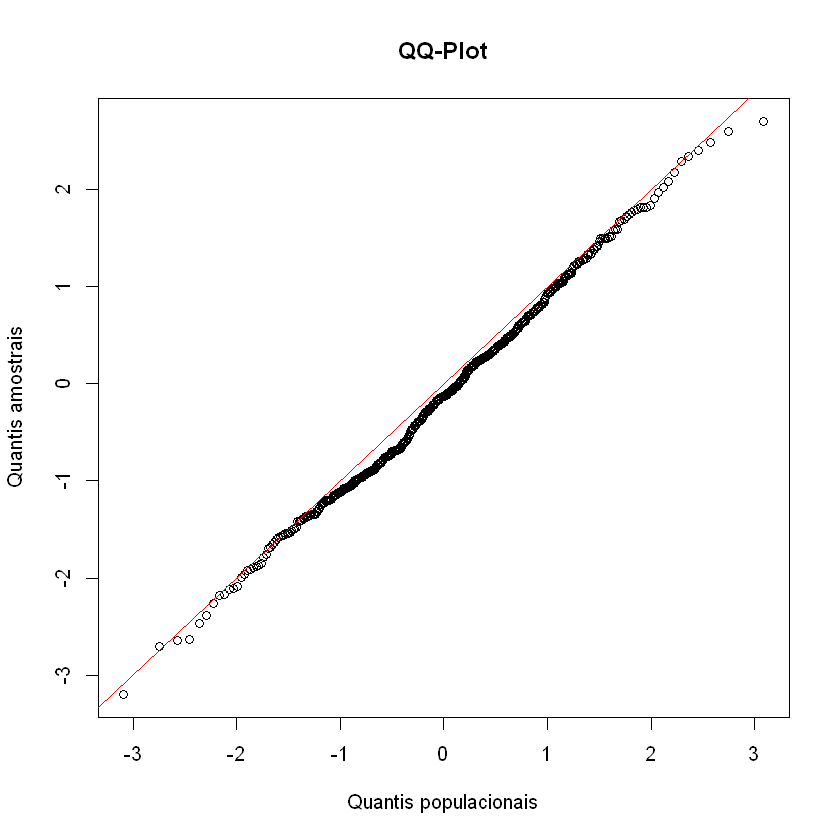

In [14]:
#ordenação:
amostra_ordenada <- sort(Y)

#quantis populacionais:
i <- 1:n #vetor de 1 a n=500
i <- (i-0.5)/n #ajustar

quantis_populacionais <- qnorm(i)

#gráfico:
plot(quantis_populacionais, amostra_ordenada,
     main = "QQ-Plot",
     xlab = "Quantis populacionais",
     ylab = "Quantis amostrais"
    )
abline(0, 1, col = "red")

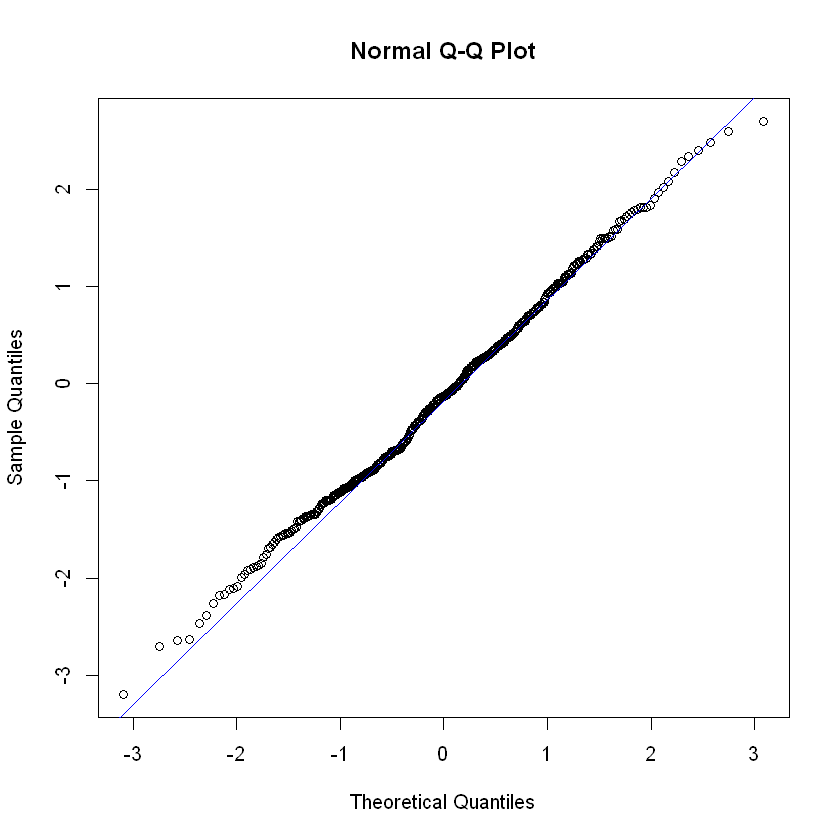

In [17]:
qqnorm(Y)
qqline(Y, col = "blue")